# Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ---- Reproducibility ----
torch.manual_seed(42)

# ---- Use GPU if available ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Processing Dataset

## Downloading Dataset

In [2]:
# Normalise pixel values to zero mean and unit variance
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # FashionMNIST mean/std
])

# torchvision downloads automatically on first run (~30 MB)
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(
    test_dataset,  batch_size=64, shuffle=False)

print()
print("---------------------------------------")
print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")
print("---------------------------------------")

# Class names for plotting
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.7MB/s]


---------------------------------------
Training batches : 938
Test batches     : 157
---------------------------------------


## Visualizing a Sample of Images

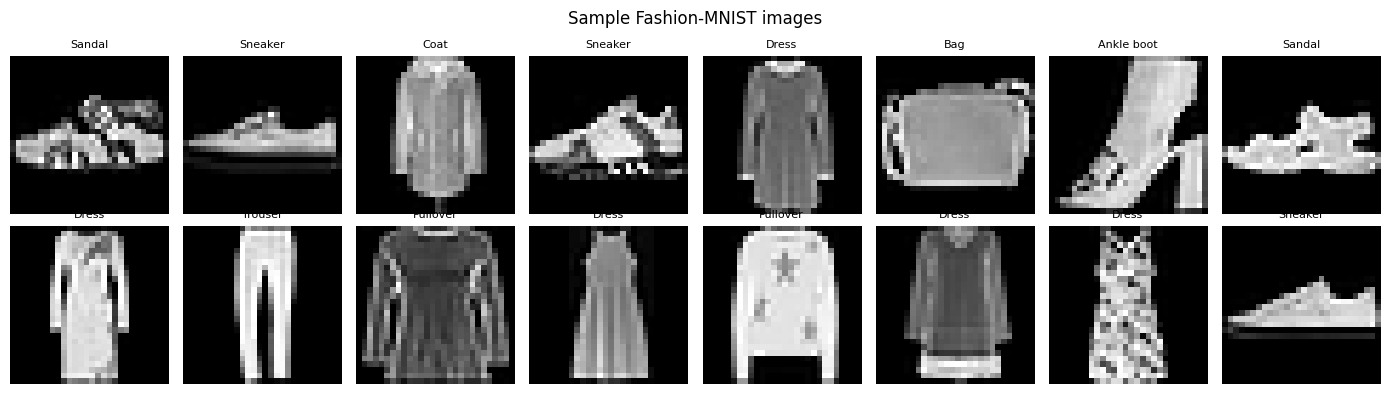


---------------------------------------
Image tensor shape: torch.Size([1, 28, 28])
Pixel range after normalisation: [-0.81, 2.02]
---------------------------------------


In [3]:
images, labels = next(iter(train_loader))   # grab one batch

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze().numpy()       # shape (28,28)
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Fashion-MNIST images", fontsize=12)
plt.tight_layout()
plt.show()

print()
print("---------------------------------------")
print(f"Image tensor shape: {images[0].shape}")   # (1, 28, 28)
print(f"Pixel range after normalisation: "
      f"[{images.min():.2f}, {images.max():.2f}]")
print("---------------------------------------")

## Building the Architecture

In [4]:
from torch.nn.modules import padding
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # ---- Convolutional Block 1 ----
        # Input:  (batch, 1, 28, 28)
        # Output: (batch, 16, 14, 14)  after pool
        self.conv_block1 = nn.Sequential(
            # ------------ YOUR CODE STARTS HERE ------------
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # ------------ YOUR CODE ENDS HERE --------------
        )

        # ---- Convolutional Block 2 ----
        # Input:  (batch, 16, 14, 14)
        # Output: (batch, 32,  7,  7)  after pool
        self.conv_block2 = nn.Sequential(
            # ------------ YOUR CODE STARTS HERE ------------
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # ------------ YOUR CODE ENDS HERE --------------
        )

        # ---- Fully-Connected Head ----
        # 32 * 7 * 7 = 1568 flattened features
        self.fc_head = nn.Sequential(
            # ------------ YOUR CODE STARTS HERE ------------
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
            # ------------ YOUR CODE ENDS HERE --------------
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc_head(x)
        return x   # raw logits (no softmax -- CrossEntropyLoss handles it)

## Training Loop

In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training set. Returns avg loss and accuracy."""
    model.train()   # enable BatchNorm/Dropout training behaviour
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear gradients from last step
        outputs = model(images)        # forward pass
        loss    = criterion(outputs, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on a data loader. Returns avg loss and accuracy."""
    model.eval()   # disable BatchNorm/Dropout training behaviour
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():              # no gradient computation needed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


def train(epochs, learning_rate=1e-3):
    model = SimpleCNN().to(device)
    print(model)
    print(f"\nTotal trainable parameters: "
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    history  = {'train_loss': [], 'test_loss': [],
                'train_acc':  [], 'test_acc':  []}

    # Define the Loss and Optimizer function
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                    optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        print(f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
            f"Test Loss:  {te_loss:.4f}  Acc: {te_acc:.4f}")

    return model

In [6]:
model = train(epochs=10, learning_rate=0.001)

SimpleCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 206,922
Epoch  1/10 | Train Loss: 0.4503  Acc: 0.8386 | Test Loss:  0.3481  Acc: 0.8703
Epoch  2/10 | Train Loss: 0.2950  Acc: 0.8911 | Test Loss:  0.2988  Acc: 0.8862
Epoch  3/10 | Train Loss: 0.2500  Acc: 0.9079 | Test Loss:  0.2795  Acc: 0.8992
Epoch  4/10 | Train Loss: 0.2207  Acc: 0.9177 | Test Loss:  0.2577  Acc: 0.9062
Epoc

## Classification Report

In [7]:
def get_classification_report(model):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            preds  = model(images).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds,
                                target_names=class_names))

    return all_preds, all_labels

# Complete the Tasks

## Task 1

In [8]:
def train(epochs, learning_rate=1e-3):
    model = SimpleCNN().to(device)
    print(model)
    print(f"\nTotal trainable parameters: "
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    history  = {'train_loss': [], 'test_loss': [],
                'train_acc':  [], 'test_acc':  []}

    #Loss function

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                    optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        print(f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
            f"Test Loss:  {te_loss:.4f}  Acc: {te_acc:.4f}")

    return model, history

In [9]:
model, history = train(epochs=10, learning_rate=0.001)

SimpleCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 206,922
Epoch  1/10 | Train Loss: 0.4565  Acc: 0.8367 | Test Loss:  0.3626  Acc: 0.8690
Epoch  2/10 | Train Loss: 0.2990  Acc: 0.8911 | Test Loss:  0.2909  Acc: 0.8933
Epoch  3/10 | Train Loss: 0.2556  Acc: 0.9065 | Test Loss:  0.2693  Acc: 0.9044
Epoch  4/10 | Train Loss: 0.2270  Acc: 0.9155 | Test Loss:  0.2634  Acc: 0.9032
Epoc

## Task 2

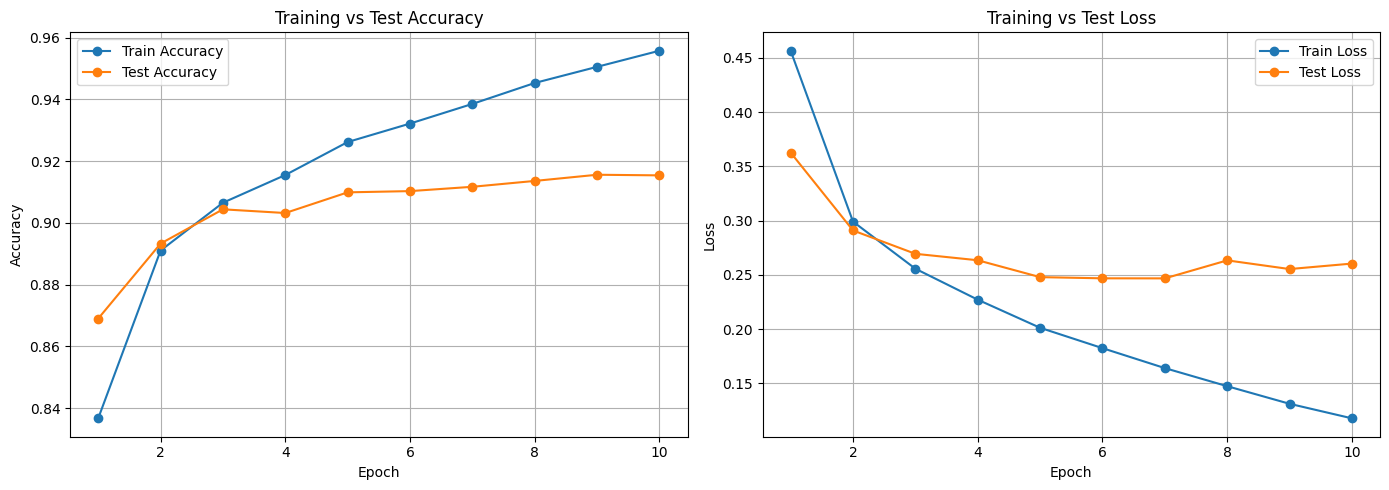

In [10]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, history['test_acc'], label='Test Accuracy', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Test Accuracy')
axes[0].legend()
axes[0].grid(True)


axes[1].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(epochs_range, history['test_loss'], label='Test Loss', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Test Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.85      0.89      0.87      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.85      0.87      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.78      0.74      0.76      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



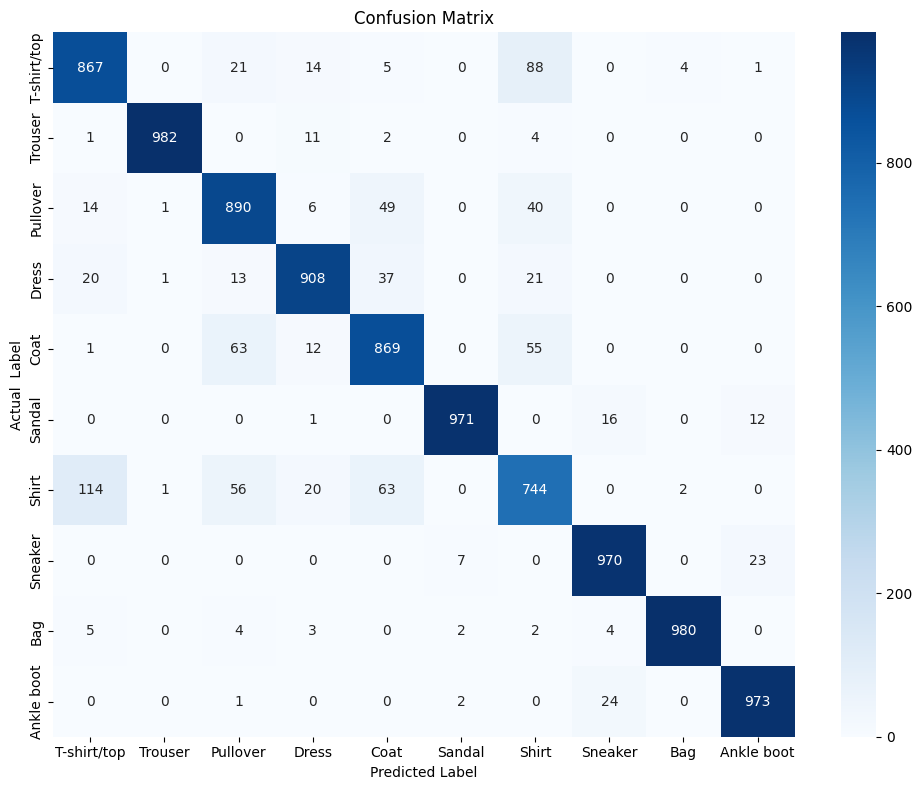

In [11]:
all_preds, all_labels = get_classification_report(model)

cm = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual  Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Task 3

In [12]:
class DropoutCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super(DropoutCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc_head(x)
        return x

In [13]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc_head(x)
        return x

In [14]:
def train_model(model_class, epochs, learning_rate=1e-3, **model_kwargs):
    model = model_class(**model_kwargs).to(device)
    print(model)
    print(f"Total trainable parameters: "
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    history  = {'train_loss': [], 'test_loss': [],
                'train_acc':  [], 'test_acc':  []}

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                    optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        print(f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
            f"Test Loss:  {te_loss:.4f}  Acc: {te_acc:.4f}")

    return model, history


In [15]:
dropout_model, dropout_history = train_model(DropoutCNN, epochs=10, learning_rate=0.001)

DropoutCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total trainable parameters: 206,922
Epoch  1/10 | Train Loss: 0.5587  Acc: 0.7979 | Test Loss:  0.3712  Acc: 0.8709
Epoch  2/10 | Train Loss: 0.3739  Acc: 0.8665 | Test Loss:  0.3134  Acc: 0.8830
Epoch  3/10 | Train Loss: 0.3242  Acc: 0.8823 | Test Loss:  0.3031  Acc: 0.8883
Epoch  4/10 | Train Loss: 0.2975  Acc: 0.8931

In [16]:
bn_model, bn_history = train_model(BatchNormCNN, epochs=10, learning_rate=0.001)

BatchNormCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total trainable parameters: 207,018
Epoch  1/10 | Train Loss: 0.3846  Acc: 0.8634 | Test Loss:  0.3458  Acc: 0.8721
Epoch  2/10 | Train Loss: 0.2682  Acc: 0.9018 | Test Loss:  0.33

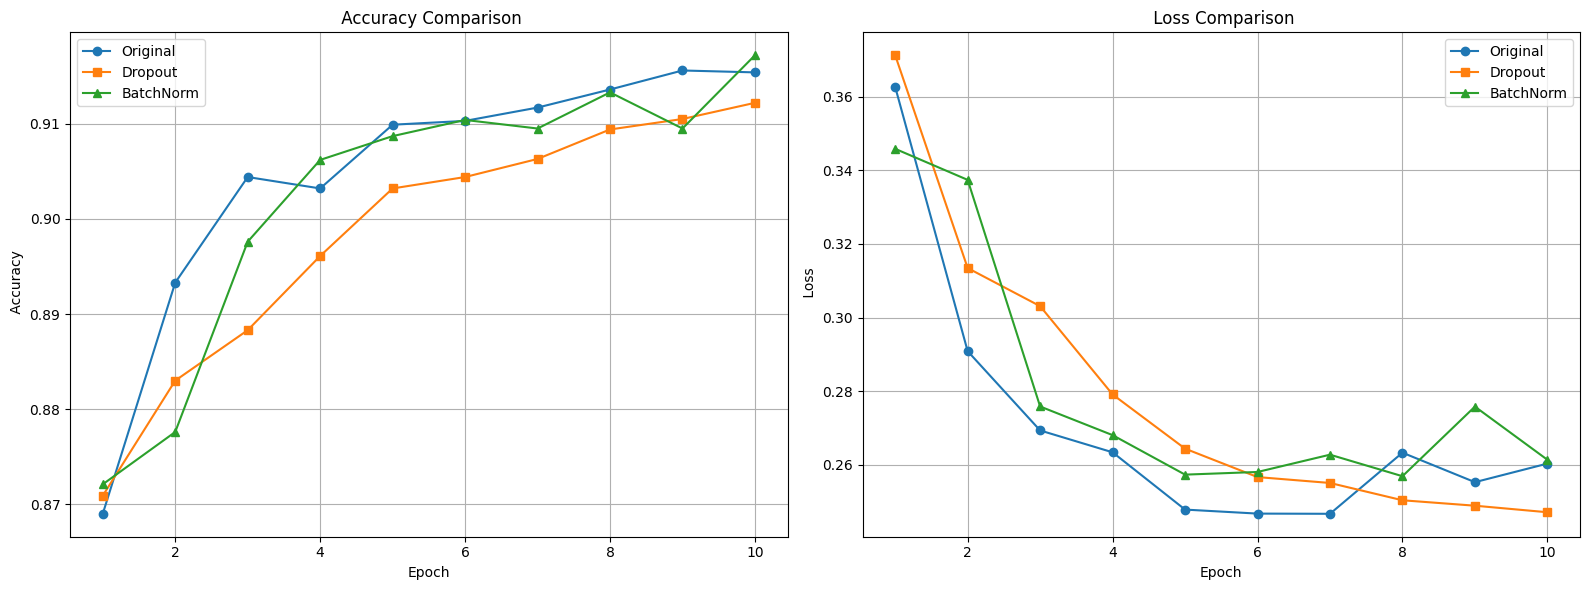

In [17]:
epochs_range = range(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Accuracy
axes[0].plot(epochs_range, history['test_acc'], label='Original', marker='o')
axes[0].plot(epochs_range, dropout_history['test_acc'], label='Dropout', marker='s')
axes[0].plot(epochs_range, bn_history['test_acc'], label='BatchNorm', marker='^')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(' Accuracy')
axes[0].set_title(' Accuracy Comparison')
axes[0].legend()
axes[0].grid(True)

#  Loss
axes[1].plot(epochs_range, history['test_loss'], label='Original', marker='o')
axes[1].plot(epochs_range, dropout_history['test_loss'], label='Dropout', marker='s')
axes[1].plot(epochs_range, bn_history['test_loss'], label='BatchNorm', marker='^')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel(' Loss')
axes[1].set_title(' Loss Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Task 4 (Bonus)

In [18]:
class SimpleFFN(nn.Module):
    """
    A plain fully-connected network that takes the flattened 28x28 image
    as input. No convolutions, no weight sharing, no spatial structure.
    Used as a baseline to compare against SimpleCNN.
    """
    def __init__(self):
        super(SimpleFFN, self).__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [19]:
ffn_model, ffn_history = train_model(SimpleFFN, epochs=10, learning_rate=0.001)

SimpleFFN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total trainable parameters: 235,146
Epoch  1/10 | Train Loss: 0.4645  Acc: 0.8306 | Test Loss:  0.3841  Acc: 0.8616
Epoch  2/10 | Train Loss: 0.3460  Acc: 0.8729 | Test Loss:  0.3631  Acc: 0.8659
Epoch  3/10 | Train Loss: 0.3126  Acc: 0.8839 | Test Loss:  0.3584  Acc: 0.8710
Epoch  4/10 | Train Loss: 0.2839  Acc: 0.8930 | Test Loss:  0.3490  Acc: 0.8744
Epoch  5/10 | Train Loss: 0.2691  Acc: 0.8988 | Test Loss:  0.3532  Acc: 0.8773
Epoch  6/10 | Train Loss: 0.2501  Acc: 0.9064 | Test Loss:  0.3542  Acc: 0.8740
Epoch  7/10 | Train Loss: 0.2351  Acc: 0.9107 | Test Loss:  0.3515  Acc: 0.8808
Epoch  8/10 | Train Loss: 0.2194  Acc: 0.9170 | Test Loss:  0.3292  Acc: 0.8897
Epoch  9/10 | Train Loss: 0